# 08 — Feature Assembly & Inspection

Loads the current v3 feature blocks and stacks them into the combined matrix that feeds the
KNN model. This notebook is **inspection only** — it writes nothing to disk. Its purpose is
to verify that all blocks are aligned, compute sparsity statistics, and determine a safe
column-pruning threshold.

## v3 feature blocks

| Block | File | Cols | Notes |
|---|---|---|---|
| genre | `album_genre_matrix.npz` | 10,255 | Combined album + artist + label tags |
| record_label | `album_record_label_matrix.npz` | 2,968 | Labels + types consolidated |
| track_stats | `album_track_stats_matrix.npz` | 12 | Min-max scaled track-length stats |
| country | `album_country_matrix.npz` | 2,014 | One-hot primary artist country |
| era | `album_era_matrix.npz` | 12 | One-hot decade/era bin |
| ratings | `album_ratings_matrix.npz` | 1 | Bayesian-weighted rating score |
| popularity | `album_lastfm_popularity_matrix.npz` | 4 | Last.fm listener/scrobble counts (optional) |

**v1 matrices archived.** The original `album_tags_matrix`, `album_labels_matrix`, and
`album_types_matrix` have been moved to `archive/` and gitignored. They are superseded by
`album_genre_matrix` (richer blended tags) and `album_record_label_matrix` (consolidated
labels + types). See `Planning/feature_review.md` for the full deprecation rationale.

**Inputs:** `data/features/album_ids.pkl` + the seven `.npz` files above

**Outputs:** None — inspection only. Assembly logic is reproduced in the KNN training notebooks.

**Run after:** `07-feature-era.ipynb`, `13-feature-lastfm-popularity.ipynb`  
**Run before:** `4-model/04-knn-v3-training.ipynb`

## Imports and setup

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, load_npz

FEATURES_DIR = '../data/features'
DATA_DIR     = '../data'

print('Environment ready.')

Environment ready.


## Load feature blocks

All v3 matrices are pre-built at the full album universe (1,758,488 rows) and aligned to
`album_ids.pkl`. No expansion step is needed — row `i` in every `.npz` refers to the same
album as row `i` in the index. (The old expansion logic was required for v1 matrices that were
built over a tag-filtered subset of ~1M albums; v3 matrices are built over the full universe
from the start.)

The popularity block is optional: loaded if the file exists, skipped gracefully if not.

In [2]:
# Load master row index
with open(f'{FEATURES_DIR}/album_ids.pkl', 'rb') as f:
    album_ids = pickle.load(f)

n_albums = len(album_ids)
print(f'Album universe: {n_albums:,} albums')

# Load v3 feature blocks
blocks = {
    'genre':        load_npz(f'{FEATURES_DIR}/album_genre_matrix.npz'),
    'record_label': load_npz(f'{FEATURES_DIR}/album_record_label_matrix.npz'),
    'track_stats':  load_npz(f'{FEATURES_DIR}/album_track_stats_matrix.npz'),
    'country':      load_npz(f'{FEATURES_DIR}/album_country_matrix.npz'),
    'era':          load_npz(f'{FEATURES_DIR}/album_era_matrix.npz'),
    'ratings':      load_npz(f'{FEATURES_DIR}/album_ratings_matrix.npz'),
}

# Popularity is optional — present if Last.fm scrape has been run
_pop_path = f'{FEATURES_DIR}/album_lastfm_popularity_matrix.npz'
if os.path.exists(_pop_path):
    blocks['popularity'] = load_npz(_pop_path)
    print('Popularity block loaded.')
else:
    print('Popularity block not found — continuing without it.')

print(f'\nBlocks loaded: {list(blocks.keys())}')

Album universe: 1,758,488 albums


Popularity block loaded.

Blocks loaded: ['genre', 'record_label', 'track_stats', 'country', 'era', 'ratings', 'popularity']


## Shapes, nnz, and coverage per block

Sanity-check that every block has the correct number of rows (`len(album_ids)`) and report
the non-zero count and **album coverage** — the percentage of albums that have at least one
non-zero entry in this block.

Coverage is a more useful health metric than raw nnz for blocks with very different column
counts. A block with 10,000 columns and 50% album coverage is very different from one with
1 column and 50% coverage.

In [3]:
print(f'{"Block":<16} {"Shape":^28} {"nnz":>12} {"coverage":>10}')
print('-' * 72)

for name, X in blocks.items():
    assert X.shape[0] == n_albums, (
        f'{name}: row count mismatch — got {X.shape[0]:,}, expected {n_albums:,}'
    )
    coverage = (X.getnnz(axis=1) > 0).sum() / n_albums * 100
    print(f'{name:<16} {str(X.shape):^28} {X.nnz:>12,} {coverage:>9.1f}%')

print('-' * 72)
X_combined = hstack(list(blocks.values())).tocsr()
combined_coverage = (X_combined.getnnz(axis=1) > 0).sum() / n_albums * 100
print(f'{"COMBINED":<16} {str(X_combined.shape):^28} {X_combined.nnz:>12,} {combined_coverage:>9.1f}%')

Block                       Shape                      nnz   coverage
------------------------------------------------------------------------
genre                  (1758488, 10275)          6,491,325      68.8%
record_label           (1758488, 2968)           1,151,408      32.7%
track_stats             (1758488, 12)           19,336,850      99.8%
country                (1758488, 2014)           1,702,671      96.8%
era                     (1758488, 10)            1,722,185      97.9%
ratings                  (1758488, 1)              341,083      19.4%
popularity               (1758488, 2)              752,974      22.1%
------------------------------------------------------------------------


COMBINED               (1758488, 15282)         31,498,496     100.0%


## Per-block column nnz breakdown

For each block, compute column nnz — how many albums have a non-zero value in each column.
The sparsity profiles differ significantly across blocks:

- **genre** — long tail of rare tags; top tags (rock, pop, electronic) appear in tens of thousands of albums
- **record_label** — most labels are small; only major labels appear in many albums
- **track_stats** — 12 dense numerical columns; every album with track data populates all 12
- **country** — 2,014 one-hot columns; every album has exactly one non-zero
- **era** — 12 one-hot columns; ~97.9% of albums have exactly one non-zero
- **ratings** — single column, sparse (~44k albums rated out of 1.76M)
- **popularity** — 4 columns; ~56% album coverage from the Last.fm scrape

The breakdown helps verify that a global pruning threshold does not inadvertently wipe out an
entire block — e.g. if all label columns have nnz < 5, a threshold of 10 would silently
eliminate the full record_label block before training.

In [4]:
print(f'{"Block":<16} {"Cols":>8} {"min nnz":>10} {"median nnz":>12} {"max nnz":>10} {"cols nnz=1":>12}')
print('-' * 74)

for name, X in blocks.items():
    col_nnz = np.diff(X.tocsc().indptr)
    singletons = (col_nnz == 1).sum()
    print(
        f'{name:<16}'
        f'{X.shape[1]:>8,}'
        f'{col_nnz.min():>10,}'
        f'{int(np.median(col_nnz)):>12,}'
        f'{col_nnz.max():>10,}'
        f'{singletons:>12,}'
    )

Block                Cols    min nnz   median nnz    max nnz   cols nnz=1
--------------------------------------------------------------------------
genre             10,275         0          28   314,865          14
record_label       2,968        10          37   202,528           0
track_stats           12    98,293   1,755,084 1,755,085           0
country            2,014         1           2   434,814         967
era                   10     5,169      73,895   529,832           0
ratings                1   341,083     341,083   341,083           0
popularity             2   365,028     376,487   387,946           0


## Column nnz distribution and CDF

A histogram of column nnz across the combined matrix (log-scale y-axis to show the long tail)
and a CDF showing what fraction of columns survive at each pruning threshold.

The CDF answers: "if I require every kept column to appear in at least N albums, how many
columns survive?" The elbow of the CDF is a useful heuristic for choosing a threshold that
removes the noise tail without cutting into genuinely useful rare-genre columns.

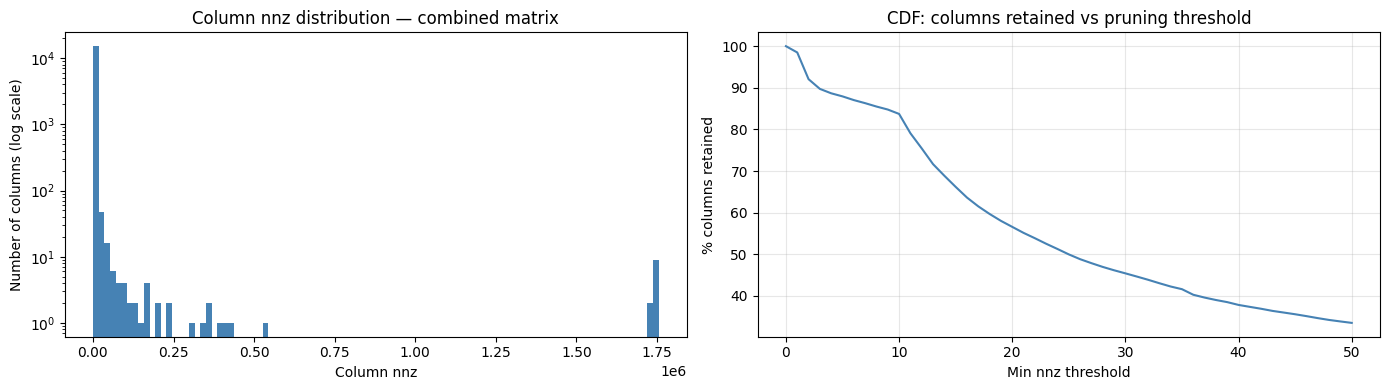

Total columns     : 15,282
Columns nnz >= 1  : 15,051
Columns nnz >= 5  : 13,439
Columns nnz >= 10 : 12,795


In [5]:
col_nnz_combined = np.diff(X_combined.tocsc().indptr)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(col_nnz_combined, bins=100, log=True, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Column nnz')
axes[0].set_ylabel('Number of columns (log scale)')
axes[0].set_title('Column nnz distribution — combined matrix')

thresholds = np.arange(0, 51)
retained = [(col_nnz_combined >= t).sum() / len(col_nnz_combined) * 100 for t in thresholds]
axes[1].plot(thresholds, retained, color='steelblue')
axes[1].set_xlabel('Min nnz threshold')
axes[1].set_ylabel('% columns retained')
axes[1].set_title('CDF: columns retained vs pruning threshold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total columns     : {len(col_nnz_combined):,}')
print(f'Columns nnz >= 1  : {(col_nnz_combined >= 1).sum():,}')
print(f'Columns nnz >= 5  : {(col_nnz_combined >= 5).sum():,}')
print(f'Columns nnz >= 10 : {(col_nnz_combined >= 10).sum():,}')

## Album zeroing analysis

The CDF shows column retention. The more critical question for recommendation quality is:
**how many albums lose all their features if we prune at threshold N?**

An album is zeroed out when every column it appears in gets dropped. This is the failure mode
the safe threshold is designed to prevent — an album that had one niche genre tag becomes a
zero-vector and KNN can no longer find neighbours for it.

This cell sweeps over a range of threshold values and counts how many albums would be zeroed
at each. The curve shows when album loss begins and how steeply it scales.

Albums with at least one feature: 1,758,462 / 1,758,488 (100.0%)


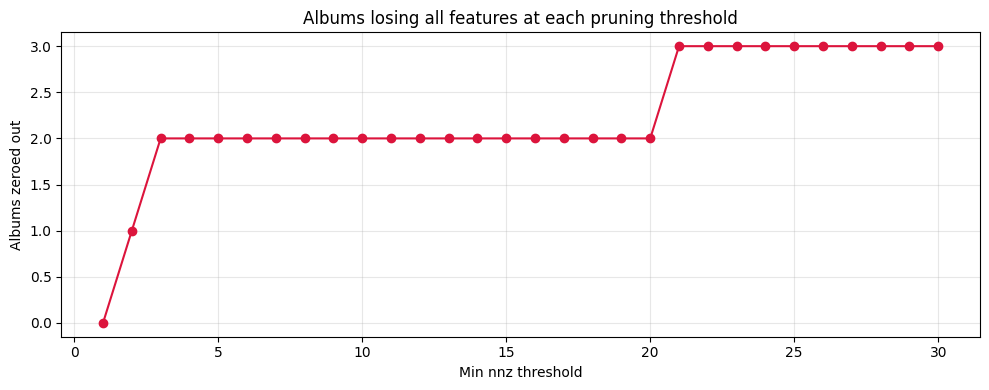

In [6]:
# Per-album maximum column nnz — the "best column" each album appears in
coo = X_combined.tocoo()
col_nnz = np.diff(X_combined.tocsc().indptr)
col_nnz_per_entry = col_nnz[coo.col]

max_col_nnz_per_album = np.zeros(n_albums, dtype=np.int32)
np.maximum.at(max_col_nnz_per_album, coo.row, col_nnz_per_entry)

has_features = max_col_nnz_per_album > 0
print(f'Albums with at least one feature: {has_features.sum():,} / {n_albums:,}'
      f' ({has_features.mean()*100:.1f}%)')

thresholds = range(1, 31)
zeroed = [((max_col_nnz_per_album < t) & has_features).sum() for t in thresholds]

plt.figure(figsize=(10, 4))
plt.plot(list(thresholds), zeroed, marker='o', color='crimson')
plt.xlabel('Min nnz threshold')
plt.ylabel('Albums zeroed out')
plt.title('Albums losing all features at each pruning threshold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Safe pruning threshold

The safe threshold is the highest column-nnz cutoff that zeros out **no** album currently in
the recommendable set. It equals `min(best_column_nnz)` across all albums with features —
any threshold above this drops the only column at least one album appears in.

The per-block survival table below shows how many columns each block contributes after
applying the safe threshold, confirming that no block is inadvertently wiped out.

In [7]:
safe_threshold = int(max_col_nnz_per_album[has_features].min())
cols_after     = (col_nnz >= safe_threshold).sum()
pct_removed    = (1 - cols_after / len(col_nnz)) * 100

print(f'Safe threshold        : {safe_threshold}')
print(f'Columns before prune  : {len(col_nnz):,}')
print(f'Columns after prune   : {cols_after:,}  ({pct_removed:.1f}% removed)')
print(f'Albums with features  : {has_features.sum():,}')
print(f'Albums zeroed at safe : 0  (by definition)')
print()
print('Per-block column survival at safe threshold:')

col_offset = 0
for name, X in blocks.items():
    block_col_nnz = col_nnz[col_offset : col_offset + X.shape[1]]
    survived = (block_col_nnz >= safe_threshold).sum()
    print(f'  {name:<16} {survived:>6,} / {X.shape[1]:>6,} columns survive')
    col_offset += X.shape[1]

Safe threshold        : 1
Columns before prune  : 15,282
Columns after prune   : 15,051  (1.5% removed)
Albums with features  : 1,758,462
Albums zeroed at safe : 0  (by definition)

Per-block column survival at safe threshold:
  genre            10,044 / 10,275 columns survive
  record_label      2,968 /  2,968 columns survive
  track_stats          12 /     12 columns survive
  country           2,014 /  2,014 columns survive
  era                  10 /     10 columns survive
  ratings               1 /      1 columns survive
  popularity            2 /      2 columns survive
